In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sys
import os

# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)

In [6]:
from package_files.benefits_defns import *

In [3]:
path_all = '../data/us_10m_nointernship_ai_skills_benefits.parquet.gzip'

In [4]:
usdf = pd.read_parquet(path_all)

In [24]:
df_select = usdf[benefits4+['SALARY']].copy()

In [9]:
df_select

,EDU_ASSISTANCE,PAID_LEAVE,HEALTH_WELLBEING,PARENTAL_LEAVE,CULTURE,wfh_wham,SALARY
0,False,True,True,False,False,0.0,NaN
1,False,False,False,False,False,0.0,NaN
2,False,False,False,False,False,0.0,NaN
3,False,False,False,False,False,0.0,NaN
4,False,False,False,False,False,0.0,NaN
...,...,...,...,...,...,...,...
11581321,False,True,False,False,False,0.0,NaN
11581322,False,False,False,False,True,0.0,NaN
11581323,False,False,False,False,False,0.0,43680.0
11581324,False,False,False,False,False,0.0,NaN


In [10]:
df_salary = df_select[df_select['SALARY'].notnull()]

In [11]:
correlation_matrix = df_salary.corr()

In [12]:
correlation_matrix

,EDU_ASSISTANCE,PAID_LEAVE,HEALTH_WELLBEING,PARENTAL_LEAVE,CULTURE,wfh_wham,SALARY
EDU_ASSISTANCE,1.000000,0.271290,0.150952,0.249303,0.089233,0.030740,0.007050
PAID_LEAVE,0.271290,1.000000,0.164372,0.221007,0.047109,0.013050,-0.032086
HEALTH_WELLBEING,0.150952,0.164372,1.000000,0.124034,0.074160,0.061734,0.020992
PARENTAL_LEAVE,0.249303,0.221007,0.124034,1.000000,0.147311,0.088551,0.059289
CULTURE,0.089233,0.047109,0.074160,0.147311,1.000000,0.097848,0.096299
wfh_wham,0.030740,0.013050,0.061734,0.088551,0.097848,1.000000,0.227687
SALARY,0.007050,-0.032086,0.020992,0.059289,0.096299,0.227687,1.000000


([<matplotlib.axis.YTick at 0x7f0daf97dbb0>,
 [Text(0, 0.5, 'Tuition Assistance'),
  Text(0, 1.5, 'Paid Leave'),
  Text(0, 2.5, 'Health and Wellbeing'),
  Text(0, 3.5, 'Parental Leave'),
  Text(0, 4.5, 'Workplace Culture'),
  Text(0, 5.5, 'Remote Work'),
  Text(0, 6.5, 'Salary')])

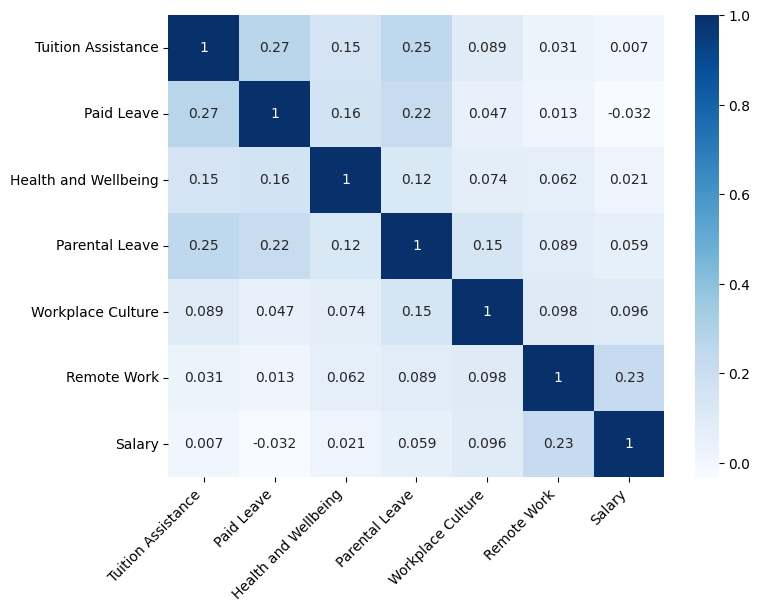

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', cbar = True)
plt.xticks(ticks=np.arange(len(correlation_matrix.columns))+0.5, labels=benefits4_labels + ['Salary'], rotation=45, ha='right')
plt.yticks(ticks=np.arange(len(correlation_matrix.columns))+0.5, labels=benefits4_labels + ['Salary'], rotation=0, va='center')

# Benefit Count

In [26]:
df_select['Benefit Count'] = df_select[benefits4].sum(axis=1)

In [28]:
df_select

,EDU_ASSISTANCE,PAID_LEAVE,HEALTH_WELLBEING,PARENTAL_LEAVE,CULTURE,wfh_wham,SALARY,Benefit Count
0,False,True,True,False,False,0.0,NaN,2.0
1,False,False,False,False,False,0.0,NaN,0.0
2,False,False,False,False,False,0.0,NaN,0.0
3,False,False,False,False,False,0.0,NaN,0.0
4,False,False,False,False,False,0.0,NaN,0.0
...,...,...,...,...,...,...,...,...
11581321,False,True,False,False,False,0.0,NaN,1.0
11581322,False,False,False,False,True,0.0,NaN,1.0
11581323,False,False,False,False,False,0.0,43680.0,0.0
11581324,False,False,False,False,False,0.0,NaN,0.0


In [27]:
df_select['Benefit Count'].value_counts()

Benefit Count
0.0    7409295
1.0    2852693
2.0     903351
3.0     301005
4.0      92964
5.0      18969
6.0       3049
Name: count, dtype: int64

<Axes: xlabel='Benefit Count', ylabel='Count'>

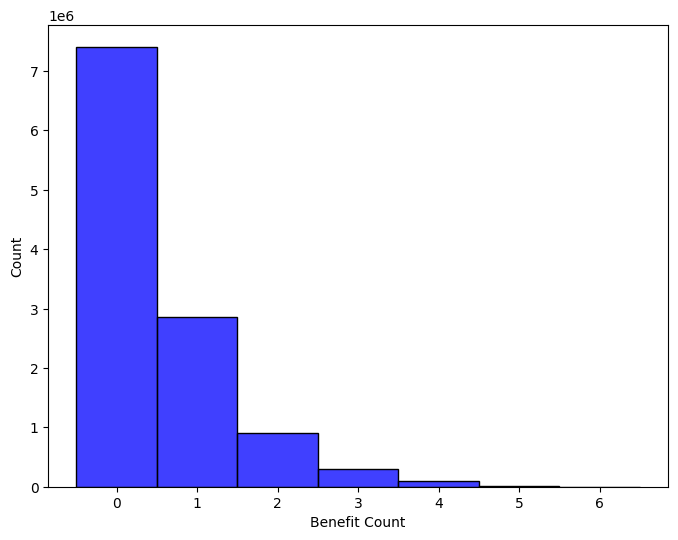

In [32]:
# plot Benefit Count
plt.figure(figsize=(8,6))
sns.histplot(df_select['Benefit Count'], bins=range(0,6), discrete=True, color='blue')

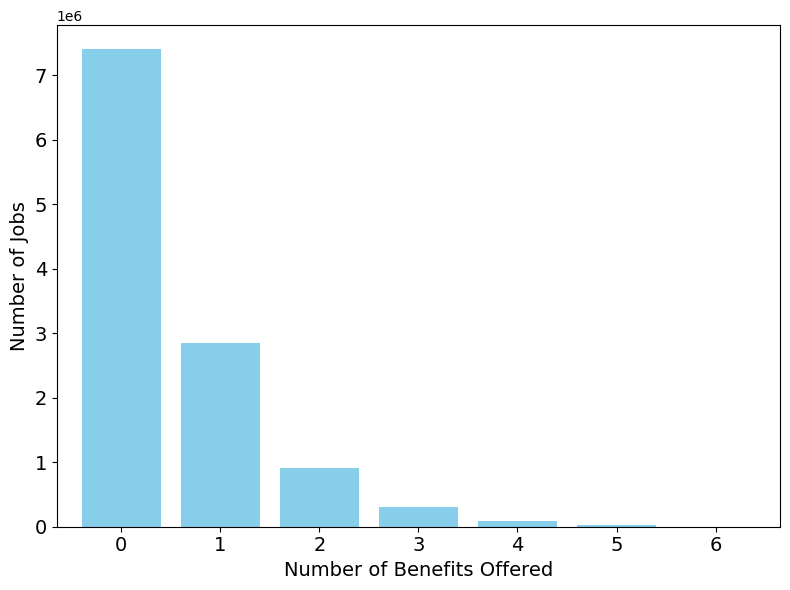

In [41]:
import matplotlib.pyplot as plt

# Assuming df_select is your DataFrame and 'Benefit Count' is already created
# Count the number of rows for each unique value in 'Benefit Count'
benefit_count_distribution = df_select['Benefit Count'].value_counts().sort_index()

# Plot the distribution as a bar chart
plt.figure(figsize=(8, 6))
ax = benefit_count_distribution.plot(kind='bar', color='skyblue', width=0.8)  # Adjust width to reduce space between bars
# ax.ticklabel_format(style='plain', axis='y')
ax.set_xticklabels(benefit_count_distribution.index.astype(int), rotation = 0, fontsize = 14)
ax.yaxis.set_tick_params(labelsize=14)


# Add labels and title
# plt.title('Number of Rows per Benefit Count', fontsize=16)
plt.xlabel('Number of Benefits Offered', fontsize=14)
plt.ylabel('Number of Jobs', fontsize=14)

# Show the plot
plt.tight_layout()
plt.show()
